# XGBoost + Lasso — Notebook Overview

## Cell-by-Cell Summary

| Cell | What happens |
|------|--------------|
| **Imports** | Load pandas, numpy, XGBRegressor, sklearn metrics + TimeSeriesSplit |
| **Load data** | Read CSV, parse datetime, sort chronologically, set target = OTA2201 price |
| **ffill** | Forward-fill any gaps in the time series |
| **Lag non-target cols** | Shift all other price nodes + energy/demand/flow cols by 24h → prevents leakage; drop originals |
| **Shape check** | Confirm 81 columns remain; verify lag columns exist, no raw price columns left |
| **Cyclical time features** | Encode hour/day-of-week/month as sin+cos pairs; add weekend flag |
| **Target lags** | Lag the target itself at 24h, 168h (1 week), 8760h (1 year) |
| **Rolling features** | Rolling mean+std over 24h, 168h, 8760h windows — all shifted by 1 to avoid leakage |
| **NaN audit** | Count missing rows introduced by lagging/rolling |
| **Drop NaNs** | Remove warmup rows (8760 rows = 1 year); 43 825 rows remain |
| **Define X / y** | Feature matrix = all columns except datetime + target; shape (43825, 91) |
| **Train/Test split** | 80% train (2020–2023), 20% test (2024) — time-ordered, no shuffle |
| **Train XGBoost** | Fit model with **reg_alpha=1.0** (Lasso penalty) + standard hyperparams |
| **Predict** | Run model on test set |
| **Evaluate** | MAE, RMSE, R² on held-out test period |
| **Time-series CV** | 5-fold expanding-window CV with same hyperparams (incl. Lasso) |
| **Avg CV metrics** | Summarise CV fold results |
| **Feature importance** | Rank all 91 features by XGBoost importance score |
| **Plot importances** | Bar chart of top 20 features |
| **[NEW] Zeroed features** | List features with importance = 0 — these were killed by the Lasso penalty |
| **[NEW] Pruned model** | Retrain on non-zero features only; compare MAE/RMSE/R² vs full model |
| **Actual vs Predicted** | Line plot of first 500 test-set hours |

## Changes Made (Lasso implementation)
- **Deleted** 3 duplicate cells (redundant NaN-check + dropna + X/y definition that appeared twice)
- **`reg_alpha=1.0`** added to main XGBoost model — this is XGBoost's built-in L1 / Lasso regularization
- **`reg_alpha=1.0`** added to CV loop model to keep evaluation consistent
- **New cell**: identifies features zeroed out by the Lasso penalty
- **New cell**: retrains a pruned model on non-zero features, prints side-by-side metric comparison

In [90]:
# import libraries

import pandas as pd
import numpy as np

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

In [91]:
# load data

df = pd.read_csv('../../Data_Processing/preprocessed_data.csv')
df["datetime_utc12"] = pd.to_datetime(df["datetime_utc12"])

df = df.sort_values("datetime_utc12").reset_index(drop=True)

target_col = "el_price_dol_MWh_OTA2201"
print(df.columns.tolist())

['datetime_utc12', 'el_price_dol_MWh_BEN2201', 'el_price_dol_MWh_HAY2201', 'el_price_dol_MWh_INV2201', 'el_price_dol_MWh_ISL2201', 'el_price_dol_MWh_KIK2201', 'el_price_dol_MWh_OTA2201', 'el_price_dol_MWh_RDF2201', 'el_price_dol_MWh_SFD2201', 'el_price_dol_MWh_WKM2201', 'Coal', 'Diesel', 'Ele', 'Gas', 'Geo', 'Hydro', 'Solar', 'Wind', 'Wood', 'palmerston_north_wind_kmh', 'palmerston_north_wind_dir_deg', 'wellington_wind_kmh', 'wellington_wind_dir_deg', 'harapaki_hawkesbay_wind_kmh', 'harapaki_hawkesbay_wind_dir_deg', 'te_uku_waikato_wind_kmh', 'te_uku_waikato_wind_dir_deg', 'kaiwera_downs_southland_wind_kmh', 'kaiwera_downs_southland_wind_dir_deg', 'auckland_shortwave_wm2', 'auckland_sunshine_s', 'christchurch_shortwave_wm2', 'christchurch_sunshine_s', 'wellington_shortwave_wm2', 'wellington_sunshine_s', 'hamilton_shortwave_wm2', 'hamilton_sunshine_s', 'tauranga_shortwave_wm2', 'tauranga_sunshine_s', 'dunedin_shortwave_wm2', 'dunedin_sunshine_s', 'auckland_temp_c', 'christchurch_temp_c'

# -------------------------------------------

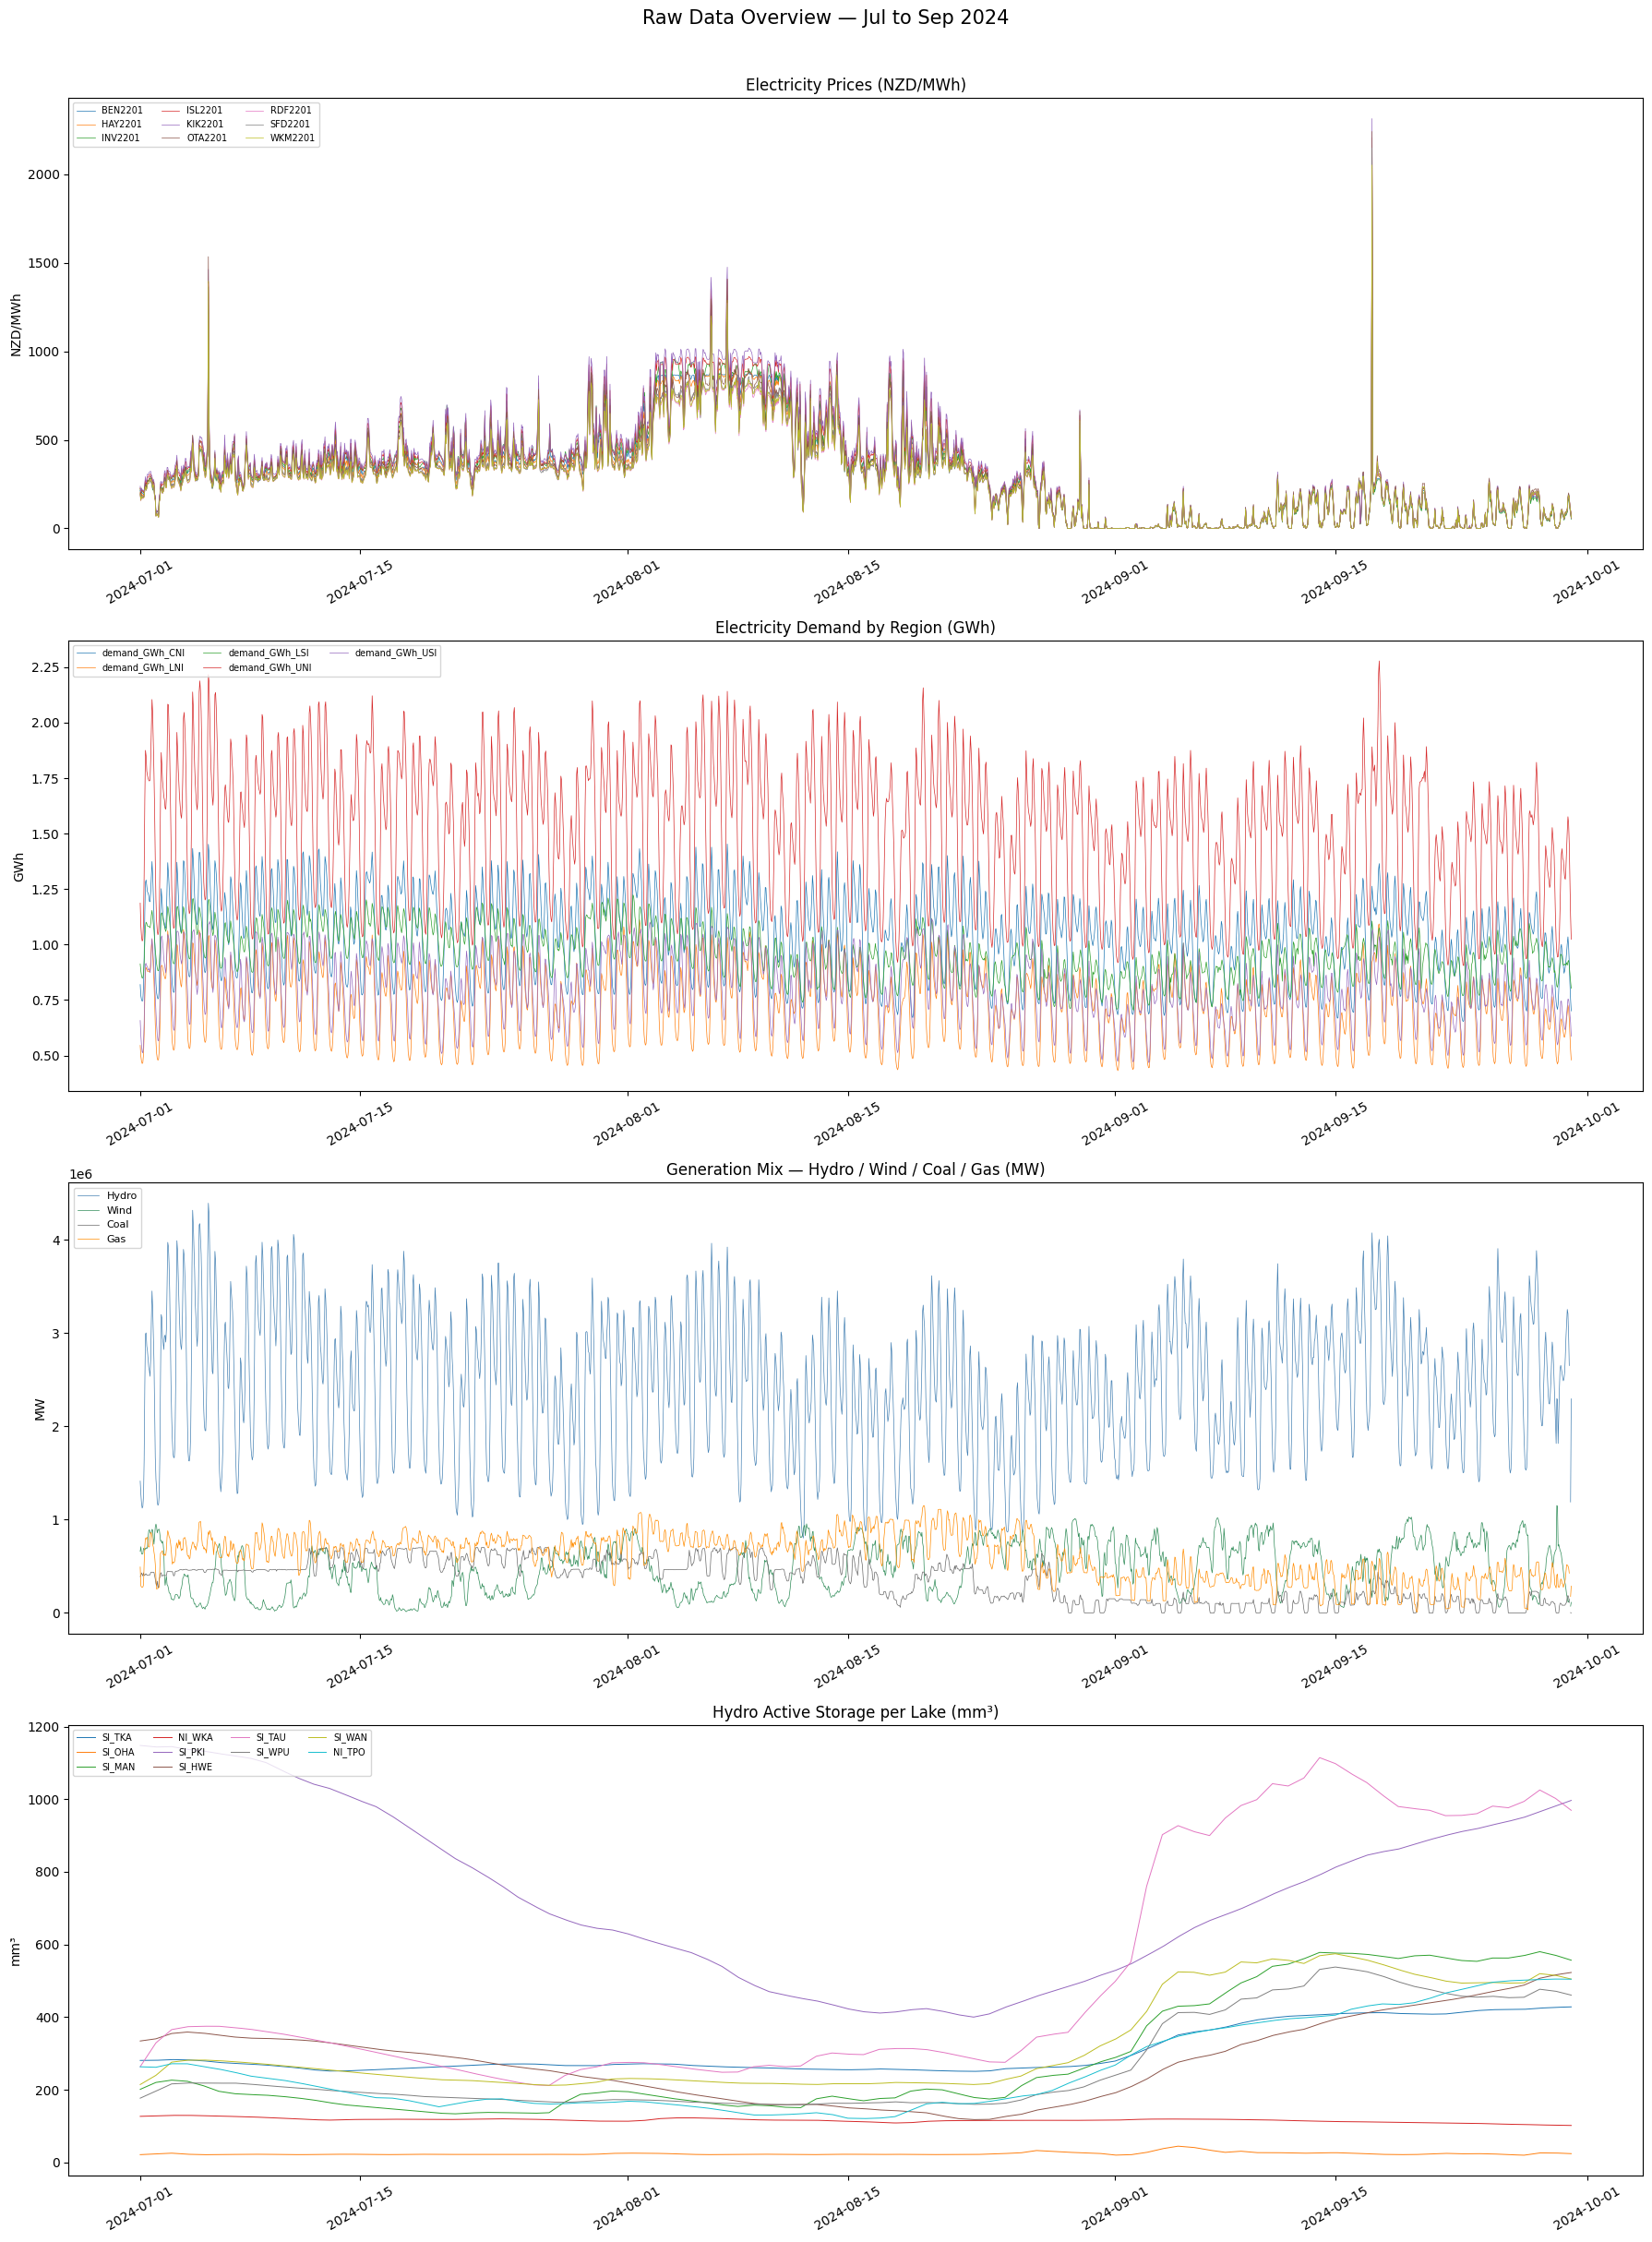

In [92]:
import matplotlib.pyplot as plt

mask = (df["datetime_utc12"] >= "2024-07-01") & (df["datetime_utc12"] <= "2024-09-30")
df_plot = df[mask]

fig, axes = plt.subplots(4, 1, figsize=(18, 24))
fig.suptitle("Raw Data Overview — Jul to Sep 2024", fontsize=15, y=1.01)

# --- 1. Electricity Prices ---
price_cols = [c for c in df.columns if "el_price" in c]
ax = axes[0]
for col in price_cols:
    ax.plot(df_plot["datetime_utc12"], df_plot[col], linewidth=0.5, label=col.split("_")[-1])
ax.set_title("Electricity Prices (NZD/MWh)")
ax.set_ylabel("NZD/MWh")
ax.legend(fontsize=7, ncol=3, loc="upper left")

# --- 2. Demand by Region ---
demand_cols = [c for c in df.columns if "demand_GWh" in c]
ax = axes[1]
for col in demand_cols:
    ax.plot(df_plot["datetime_utc12"], df_plot[col], linewidth=0.5, label=col)
ax.set_title("Electricity Demand by Region (GWh)")
ax.set_ylabel("GWh")
ax.legend(fontsize=7, ncol=3, loc="upper left")

# --- 3. Generation: Hydro, Wind, Coal, Gas ---
gen_cols = ["Hydro", "Wind", "Coal", "Gas"]
colors   = ["steelblue", "seagreen", "dimgray", "darkorange"]
ax = axes[2]
for col, color in zip(gen_cols, colors):
    ax.plot(df_plot["datetime_utc12"], df_plot[col], linewidth=0.5, label=col, color=color)
ax.set_title("Generation Mix — Hydro / Wind / Coal / Gas (MW)")
ax.set_ylabel("MW")
ax.legend(fontsize=8, loc="upper left")

# --- 4. Hydro Storage (active storage per lake) ---
storage_cols = [c for c in df.columns if "active_storage" in c]
ax = axes[3]
for col in storage_cols:
    label = col.split("__")[0]
    ax.plot(df_plot["datetime_utc12"], df_plot[col], linewidth=0.7, label=label)
ax.set_title("Hydro Active Storage per Lake (mm³)")
ax.set_ylabel("mm³")
ax.legend(fontsize=7, ncol=4, loc="upper left")

for ax in axes:
    ax.tick_params(axis="x", labelrotation=30)

plt.tight_layout()
plt.show()

# ---------------------------------------------

In [93]:
df = df.ffill()

In [94]:
# Remove all other electricity price columns
# Keep only the target price column

cols_to_shift_24h = [
    c for c in df.columns
    if "el_price" in c and c != target_col
] + [
    "Coal", "Diesel", "Ele", "Gas", "Geo", "Hydro", "Solar", "Wind", "Wood",
    "demand_GWh_CNI", "demand_GWh_LNI", "demand_GWh_LSI", "demand_GWh_UNI", "demand_GWh_USI",
    "avg_flow_MW", "peak_flow_MW", "Direction"
]

for col in cols_to_shift_24h:
    df[f"{col}_lag24"] = df[col].shift(24)
    df = df.drop(columns=[col])

In [95]:
print("Remaining dataframe shape:", df.shape)

price_cols_check = [
    c for c in df.columns
    if "el_price" in c and c != target_col
]

print("Remaining other price columns:", price_cols_check)

Remaining dataframe shape: (52585, 81)
Remaining other price columns: ['el_price_dol_MWh_BEN2201_lag24', 'el_price_dol_MWh_HAY2201_lag24', 'el_price_dol_MWh_INV2201_lag24', 'el_price_dol_MWh_ISL2201_lag24', 'el_price_dol_MWh_KIK2201_lag24', 'el_price_dol_MWh_RDF2201_lag24', 'el_price_dol_MWh_SFD2201_lag24', 'el_price_dol_MWh_WKM2201_lag24']


In [96]:
# Create cyclical time features

import numpy as np

# Basic time components
df["hour"] = df["datetime_utc12"].dt.hour
df["dayofweek"] = df["datetime_utc12"].dt.dayofweek
df["month"] = df["datetime_utc12"].dt.month
df["dayofyear"] = df["datetime_utc12"].dt.dayofyear

# Weekend indicator
df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)

# -----------------------------
# Cyclical encoding
# -----------------------------

# Hour
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

# Day of week
df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)

# Month
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

print("Time features created successfully.")

Time features created successfully.


In [97]:
# Create target lag features: daily, weekly, yearly

# Daily lag: same hour yesterday
df["target_lag_24h"] = df[target_col].shift(24)

# Weekly lag: same hour last week
df["target_lag_168h"] = df[target_col].shift(168)

# Yearly lag: same hour last year
df["target_lag_8760h"] = df[target_col].shift(8760)

print("Target lag features created.")
print(df[["target_lag_24h", "target_lag_168h", "target_lag_8760h"]].isna().sum())

Target lag features created.
target_lag_24h        24
target_lag_168h      168
target_lag_8760h    8760
dtype: int64


In [98]:
# Leakage-safe rolling window features

# -----------------------------------
# Daily rolling features (24h)
# -----------------------------------

df["rolling_mean_24h"] = (
    df[target_col]
    .shift(1)
    .rolling(window=24)
    .mean()
)

df["rolling_std_24h"] = (
    df[target_col]
    .shift(1)
    .rolling(window=24)
    .std()
)

# -----------------------------------
# Weekly rolling features (168h)
# -----------------------------------

df["rolling_mean_168h"] = (
    df[target_col]
    .shift(1)
    .rolling(window=168)
    .mean()
)

df["rolling_std_168h"] = (
    df[target_col]
    .shift(1)
    .rolling(window=168)
    .std()
)

# -----------------------------------
# Yearly rolling features (8760h)
# -----------------------------------

df["rolling_mean_8760h"] = (
    df[target_col]
    .shift(1)
    .rolling(window=8760)
    .mean()
)

df["rolling_std_8760h"] = (
    df[target_col]
    .shift(1)
    .rolling(window=8760)
    .std()
)

print("Rolling window features created successfully.")

print(df[[
    "rolling_mean_24h",
    "rolling_mean_168h",
    "rolling_mean_8760h"
]].isna().sum())

Rolling window features created successfully.
rolling_mean_24h        24
rolling_mean_168h      168
rolling_mean_8760h    8760
dtype: int64


In [99]:
# Check missing values before final cleanup

missing_summary = df.isna().sum()

missing_summary = missing_summary[missing_summary > 0]

print(missing_summary.sort_values(ascending=False).head(20))

target_lag_8760h                  8760
rolling_mean_8760h                8760
rolling_std_8760h                 8760
rolling_mean_168h                  168
rolling_std_168h                   168
target_lag_168h                    168
el_price_dol_MWh_HAY2201_lag24      24
el_price_dol_MWh_BEN2201_lag24      24
el_price_dol_MWh_INV2201_lag24      24
el_price_dol_MWh_ISL2201_lag24      24
Ele_lag24                           24
Gas_lag24                           24
el_price_dol_MWh_KIK2201_lag24      24
el_price_dol_MWh_RDF2201_lag24      24
el_price_dol_MWh_SFD2201_lag24      24
el_price_dol_MWh_WKM2201_lag24      24
Coal_lag24                          24
Diesel_lag24                        24
demand_GWh_CNI_lag24                24
Wood_lag24                          24
dtype: int64


In [100]:
# Final cleanup after all feature engineering

rows_before = len(df)

df = df.dropna().reset_index(drop=True)

rows_after = len(df)

print(f"Rows before cleanup: {rows_before}")
print(f"Rows after cleanup: {rows_after}")
print(f"Rows removed: {rows_before - rows_after}")

Rows before cleanup: 52585
Rows after cleanup: 43825
Rows removed: 8760


In [101]:
# Define target

target_col = "el_price_dol_MWh_OTA2201"

# Exclude non-feature columns

exclude_cols = [
    "datetime_utc12",
    target_col
]

# Create feature list

feature_cols = [
    c for c in df.columns
    if c not in exclude_cols
]

# Define X and y

X = df[feature_cols]
y = df[target_col]

# Check shapes

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Number of features:", len(feature_cols))

# Confirm other electricity price columns were removed

remaining_price_cols = [
    c for c in X.columns
    if "el_price" in c
]

print("Remaining price columns in X:")
print(remaining_price_cols)

Feature matrix shape: (43825, 99)
Target shape: (43825,)
Number of features: 99
Remaining price columns in X:
['el_price_dol_MWh_BEN2201_lag24', 'el_price_dol_MWh_HAY2201_lag24', 'el_price_dol_MWh_INV2201_lag24', 'el_price_dol_MWh_ISL2201_lag24', 'el_price_dol_MWh_KIK2201_lag24', 'el_price_dol_MWh_RDF2201_lag24', 'el_price_dol_MWh_SFD2201_lag24', 'el_price_dol_MWh_WKM2201_lag24']


In [102]:
# -----------------------------------
# Time-based Train/Test Split
# -----------------------------------

split_ratio = 0.8

split_index = int(len(df) * split_ratio)

# Training data
X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]

# Testing data
X_test = X.iloc[split_index:]
y_test = y.iloc[split_index:]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain period:")
print(df["datetime_utc12"].iloc[0], "to",
      df["datetime_utc12"].iloc[split_index - 1])

print("\nTest period:")
print(df["datetime_utc12"].iloc[split_index], "to",
      df["datetime_utc12"].iloc[-1])

Train shape: (35060, 99)
Test shape: (8765, 99)

Train period:
2020-01-01 00:00:00 to 2023-12-31 19:00:00

Test period:
2023-12-31 20:00:00 to 2024-12-31 00:00:00


In [103]:
# Train XGBoost model
# CHANGE [Lasso]: added reg_alpha=1.0 — L1 regularization equivalent to Lasso penalty.
# This pushes weights of less-useful splits toward zero, causing low-importance features to score 0.

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,   # L1 / Lasso penalty
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


In [104]:
# Make predictions — clipped to >= 0 (prices cannot be negative)

y_pred = xgb_model.predict(X_test)
y_pred = np.clip(y_pred, 0, None)

print("Predictions completed (clipped to >= 0).")
print(y_pred[:10])

Predictions completed (clipped to >= 0).
[113.3584   104.283936  76.887535  54.860588  58.102016  57.717205
  45.80063   46.95321   37.497803  66.405464]


In [105]:
# Evaluate model performance

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MAE  : 55.5142
RMSE : 126.5030
R²   : 0.5493


In [106]:
# ---------------------------------------------------
# Naive baseline — yesterday same hour as prediction
# ---------------------------------------------------
# The naive model predicts today's price = same hour yesterday.
# This is target_lag_24h, which is already in X_test.
#
# Metrics:
#   MAE   — Mean Absolute Error (same unit as price, NZD/MWh)
#   MAPE  — Mean Absolute Percentage Error (%, intuitive scale)
#   MASE  — Mean Absolute Scaled Error = MAE_model / MAE_naive
#           < 1 : model beats naive
#           = 1 : same as naive
#           > 1 : worse than naive
#
# Note: MAPE is undefined when actual = 0. Any zero/negative prices
# are excluded from MAPE calculation only.

y_naive = X_test["target_lag_24h"].values   # yesterday same hour

# --- Metrics helper ---
def compute_metrics(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # MAPE — exclude zeros/negatives to avoid division issues
    nonzero = y_true != 0
    mape = np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100

    return {"label": label, "MAE": mae, "RMSE": rmse, "MAPE": mape}

naive_metrics = compute_metrics(y_test.values, y_naive,  "Naive (lag 24h)")
model_metrics = compute_metrics(y_test.values, y_pred,   "XGBoost")

# MASE = MAE_model / MAE_naive
mase = model_metrics["MAE"] / naive_metrics["MAE"]

# --- Print comparison table ---
print(f"{'Metric':<8} {'Naive (lag 24h)':>18} {'XGBoost':>12}")
print("-" * 42)
for key in ["MAE", "RMSE", "MAPE"]:
    print(f"{key:<8} {naive_metrics[key]:>18.4f} {model_metrics[key]:>12.4f}")
print("-" * 42)
print(f"{'MASE':<8} {'—':>18} {mase:>12.4f}  {'✓ beats naive' if mase < 1 else '✗ worse than naive'}")

Metric      Naive (lag 24h)      XGBoost
------------------------------------------
MAE                 56.2779      55.5142
RMSE               143.1421     126.5030
MAPE              5437.6048    8878.7784
------------------------------------------
MASE                      —       0.9864  ✓ beats naive


In [107]:
# Time-series cross validation
# CHANGE [Lasso]: reg_alpha=1.0 added to CV model to keep it consistent with main model.

tscv = TimeSeriesSplit(n_splits=5)

mae_scores = []
rmse_scores = []
r2_scores = []

fold = 1

for train_index, test_index in tscv.split(X):

    X_train_cv = X.iloc[train_index]
    X_test_cv = X.iloc[test_index]

    y_train_cv = y.iloc[train_index]
    y_test_cv = y.iloc[test_index]

    model_cv = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=1.0,   # L1 / Lasso penalty
        random_state=42,
        n_jobs=-1
    )

    model_cv.fit(X_train_cv, y_train_cv)

    y_pred_cv = model_cv.predict(X_test_cv)

    mae = mean_absolute_error(y_test_cv, y_pred_cv)
    rmse = np.sqrt(mean_squared_error(y_test_cv, y_pred_cv))
    r2 = r2_score(y_test_cv, y_pred_cv)

    mae_scores.append(mae)
    rmse_scores.append(rmse)
    r2_scores.append(r2)

    print(f"\nFold {fold}")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")

    fold += 1


Fold 1
MAE  : 57.1662
RMSE : 89.2137
R²   : 0.3910

Fold 2
MAE  : 38.2970
RMSE : 58.8403
R²   : 0.5708

Fold 3
MAE  : 36.5670
RMSE : 64.2790
R²   : 0.5364

Fold 4
MAE  : 42.7131
RMSE : 89.7333
R²   : 0.3710

Fold 5
MAE  : 57.7642
RMSE : 131.4297
R²   : 0.5718


In [108]:
print("\nAverage Cross-Validation Results")

print(f"Average MAE  : {np.mean(mae_scores):.4f}")
print(f"Average RMSE : {np.mean(rmse_scores):.4f}")
print(f"Average R²   : {np.mean(r2_scores):.4f}")


Average Cross-Validation Results
Average MAE  : 46.5015
Average RMSE : 86.6992
Average R²   : 0.4882


In [109]:
# Feature importance

importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print(importance_df.head(20))

                           feature  importance
59  el_price_dol_MWh_RDF2201_lag24    0.166903
93                rolling_mean_24h    0.134876
58  el_price_dol_MWh_KIK2201_lag24    0.133927
61  el_price_dol_MWh_WKM2201_lag24    0.052757
57  el_price_dol_MWh_ISL2201_lag24    0.025464
90                  target_lag_24h    0.024931
29      SI_TKA__active_storage_mm³    0.017783
97              rolling_mean_8760h    0.017440
28            SI_TKA__lake_level_m    0.015106
60  el_price_dol_MWh_SFD2201_lag24    0.014264
26                 tauranga_temp_c    0.013744
79                            hour    0.013152
88                       month_sin    0.011178
74            demand_GWh_UNI_lag24    0.010649
75            demand_GWh_USI_lag24    0.010571
63                    Diesel_lag24    0.009172
24               wellington_temp_c    0.009050
55  el_price_dol_MWh_HAY2201_lag24    0.008663
73            demand_GWh_LSI_lag24    0.008536
91                 target_lag_168h    0.008138


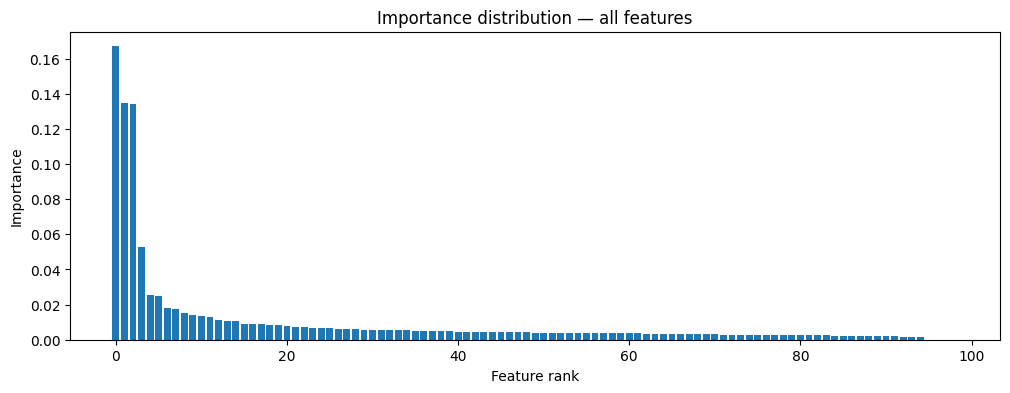

In [110]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.bar(range(len(importance_df)), importance_df["importance"].values)
plt.xlabel("Feature rank")
plt.ylabel("Importance")
plt.title("Importance distribution — all features")
plt.show()

In [111]:
# Feature selection by importance threshold
# Features below the threshold are dropped from the pruned model.

IMPORTANCE_THRESHOLD = 0.001

below_threshold = importance_df[importance_df["importance"] < IMPORTANCE_THRESHOLD]
above_threshold = importance_df[importance_df["importance"] >= IMPORTANCE_THRESHOLD]

print(f"Importance threshold      : {IMPORTANCE_THRESHOLD}")
print(f"Total features            : {len(importance_df)}")
print(f"Dropped (below threshold) : {len(below_threshold)}")
print(f"Retained                  : {len(above_threshold)}")

print("\nDropped features:")
for f in below_threshold["feature"].tolist():
    print(f"  - {f}")

Importance threshold      : 0.001
Total features            : 99
Dropped (below threshold) : 4
Retained                  : 95

Dropped features:
  - Solar_lag24
  - Ele_lag24
  - is_weekend
  - Direction_lag24


In [112]:
# Retrain pruned model using only features above the importance threshold.

selected_features = above_threshold["feature"].tolist()
print(f"Using {len(selected_features)} features (dropped {len(below_threshold)}).")

X_train_pruned = X_train[selected_features]
X_test_pruned  = X_test[selected_features]

xgb_pruned = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=5.0,
    random_state=42,
    n_jobs=-1
)

xgb_pruned.fit(X_train_pruned, y_train)

y_pred_pruned = np.clip(xgb_pruned.predict(X_test_pruned), 0, None)

mae_base  = mean_absolute_error(y_test, y_pred)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred))
r2_base   = r2_score(y_test, y_pred)

mae_p  = mean_absolute_error(y_test, y_pred_pruned)
rmse_p = np.sqrt(mean_squared_error(y_test, y_pred_pruned))
r2_p   = r2_score(y_test, y_pred_pruned)

print(f"\n{'Metric':<8} {'Full model':>12} {'Pruned model':>14}")
print("-" * 36)
print(f"{'MAE':<8} {mae_base:>12.4f} {mae_p:>14.4f}")
print(f"{'RMSE':<8} {rmse_base:>12.4f} {rmse_p:>14.4f}")
print(f"{'R²':<8} {r2_base:>12.4f} {r2_p:>14.4f}")

Using 95 features (dropped 4).

Metric     Full model   Pruned model
------------------------------------
MAE           55.5142        55.3648
RMSE         126.5030       126.2550
R²             0.5493         0.5511


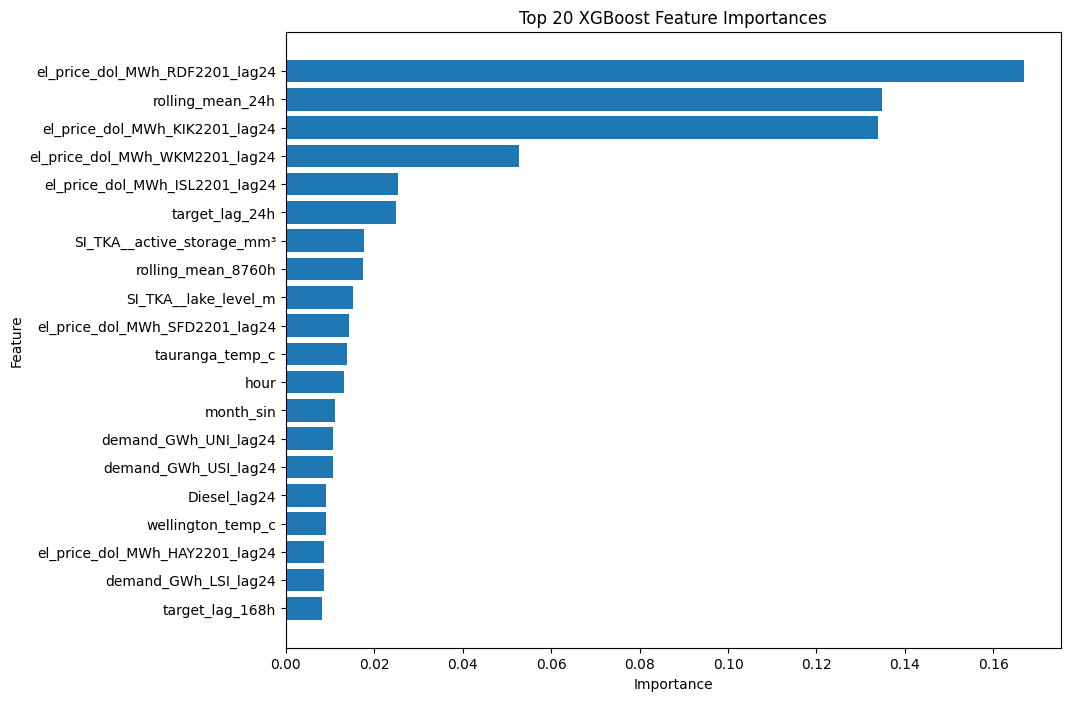

In [113]:
import matplotlib.pyplot as plt

# Top 20 feature importance

top_features = importance_df.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title("Top 20 XGBoost Feature Importances")

plt.show()

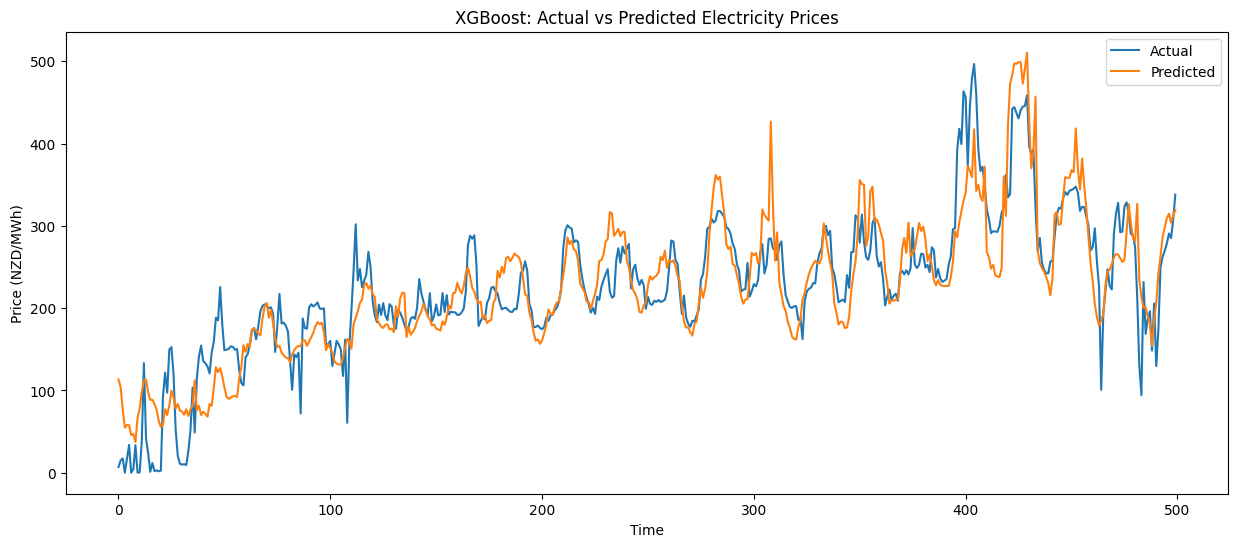

In [114]:
import matplotlib.pyplot as plt

# Plot actual vs predicted

plt.figure(figsize=(15,6))

plt.plot(
    y_test.values[:500],
    label="Actual"
)

plt.plot(
    y_pred[:500],
    label="Predicted"
)

plt.title("XGBoost: Actual vs Predicted Electricity Prices")
plt.xlabel("Time")
plt.ylabel("Price (NZD/MWh)")

plt.legend()

plt.show()

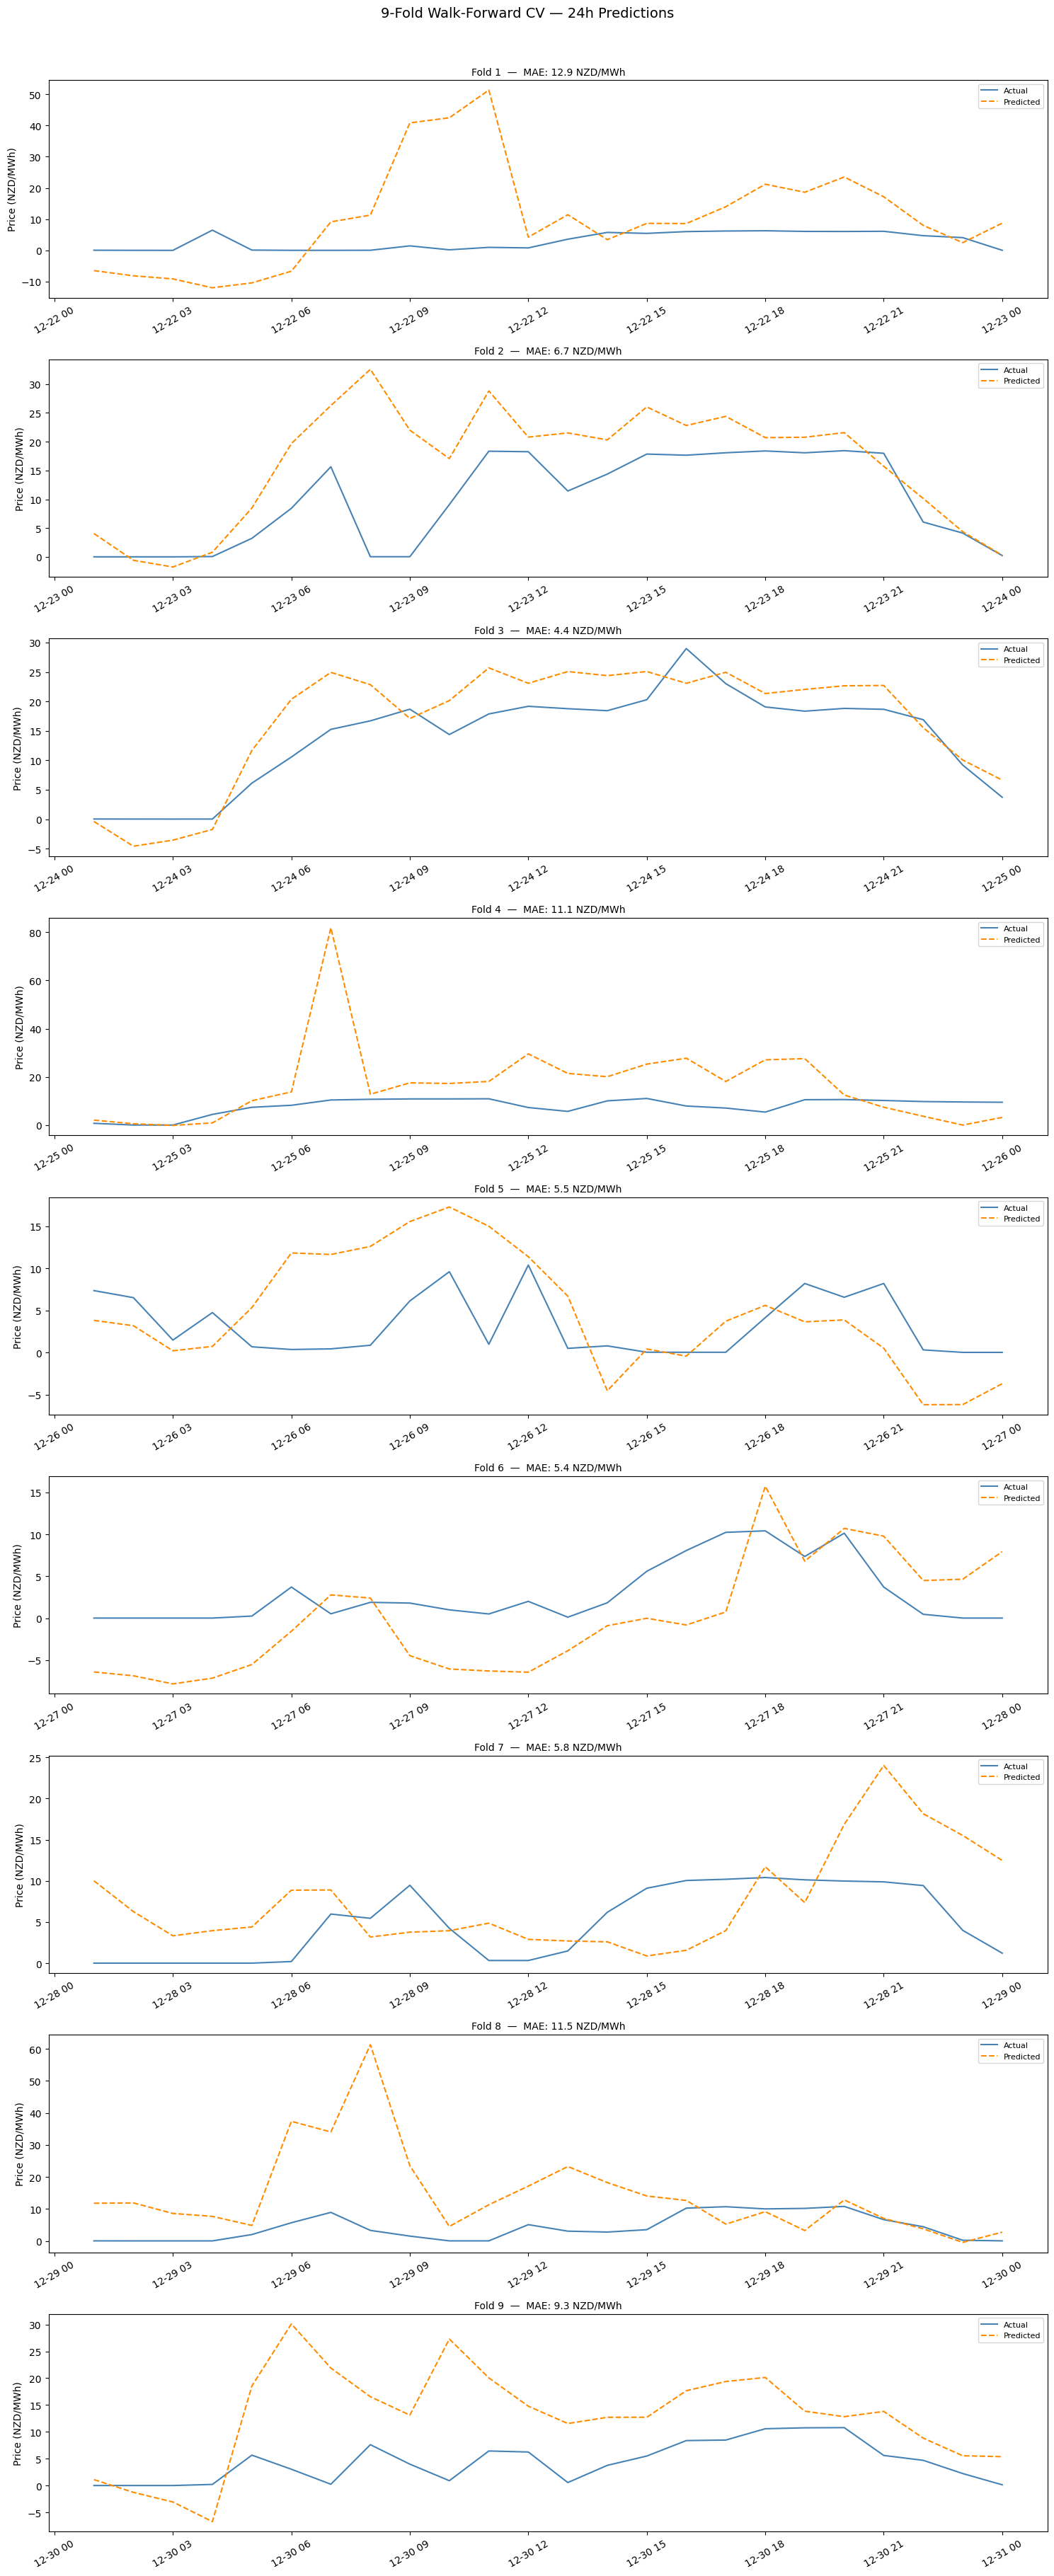


Average MAE across 9 folds: 8.06 NZD/MWh


In [115]:
# ---------------------------------------------------
# 9-Fold Walk-Forward CV — each fold predicts 24h
# ---------------------------------------------------
# Each fold trains on all data before the test window,
# then predicts the next 24 hours. Results are plotted
# as actual vs predicted per fold.

tscv_24h = TimeSeriesSplit(n_splits=9, test_size=24)

fig, axes = plt.subplots(9, 1, figsize=(15, 36), sharex=False)
fig.suptitle("9-Fold Walk-Forward CV — 24h Predictions", fontsize=14, y=1.01)

mae_scores_24h = []

for fold, ((train_idx, test_idx), ax) in enumerate(zip(tscv_24h.split(X), axes), start=1):

    X_tr = X.iloc[train_idx]
    X_te = X.iloc[test_idx]
    y_tr = y.iloc[train_idx]
    y_te = y.iloc[test_idx]

    m = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=1.0,
        random_state=42,
        n_jobs=-1
    )
    m.fit(X_tr, y_tr)
    y_p = m.predict(X_te)

    fold_mae = mean_absolute_error(y_te, y_p)
    mae_scores_24h.append(fold_mae)

    # Get datetime labels for x-axis
    timestamps = df["datetime_utc12"].iloc[test_idx].values

    ax.plot(timestamps, y_te.values, label="Actual", color="steelblue", linewidth=1.5)
    ax.plot(timestamps, y_p, label="Predicted", color="darkorange",
            linestyle="--", linewidth=1.5)
    ax.set_title(f"Fold {fold}  —  MAE: {fold_mae:.1f} NZD/MWh", fontsize=10)
    ax.set_ylabel("Price (NZD/MWh)")
    ax.legend(loc="upper right", fontsize=8)
    ax.tick_params(axis="x", labelrotation=30)

plt.tight_layout()
plt.show()

print(f"\nAverage MAE across 9 folds: {np.mean(mae_scores_24h):.2f} NZD/MWh")

In [116]:
# ---------------------------------------------------
# Rolling 14-day forecast function
# ---------------------------------------------------
# Predicts 24h at a time and chains the days together.
# All features — including price lags — use real observed
# values throughout. This reflects reality: when you run
# the forecast each morning, yesterday's actual prices are known.

def rolling_14day_forecast(model, start_date, n_days=14):
    """
    Chain n_days × 24h predictions starting from start_date.
    All lag features use actual historical values (no feedback loop).
    """
    start_ts = pd.Timestamp(start_date)
    end_ts   = start_ts + pd.Timedelta(hours=n_days * 24)

    mask = (df["datetime_utc12"] >= start_ts) & (df["datetime_utc12"] < end_ts)
    window_df = df[mask].reset_index(drop=True)

    if len(window_df) < n_days * 24:
        raise ValueError(f"Not enough data for {n_days} days from {start_date}. "
                         f"Got {len(window_df)} rows, need {n_days * 24}.")

    X_window   = window_df[feature_cols].values
    y_actual   = window_df[target_col].values
    timestamps = window_df["datetime_utc12"].values

    all_preds = []

    for day in range(n_days):
        s = day * 24
        e = s + 24
        preds = model.predict(X_window[s:e])
        all_preds.extend(preds.tolist())

    return np.array(all_preds), y_actual, timestamps


print("rolling_14day_forecast() defined — ready to use.")

rolling_14day_forecast() defined — ready to use.


Summer (Jan 2024)          MAE=31.73  start=2024-01-08
Autumn (Apr 2024)          MAE=32.86  start=2024-04-01
Winter (Jul 2024)          MAE=72.12  start=2024-07-01
Spring (Oct 2024)          MAE=34.65  start=2024-10-01


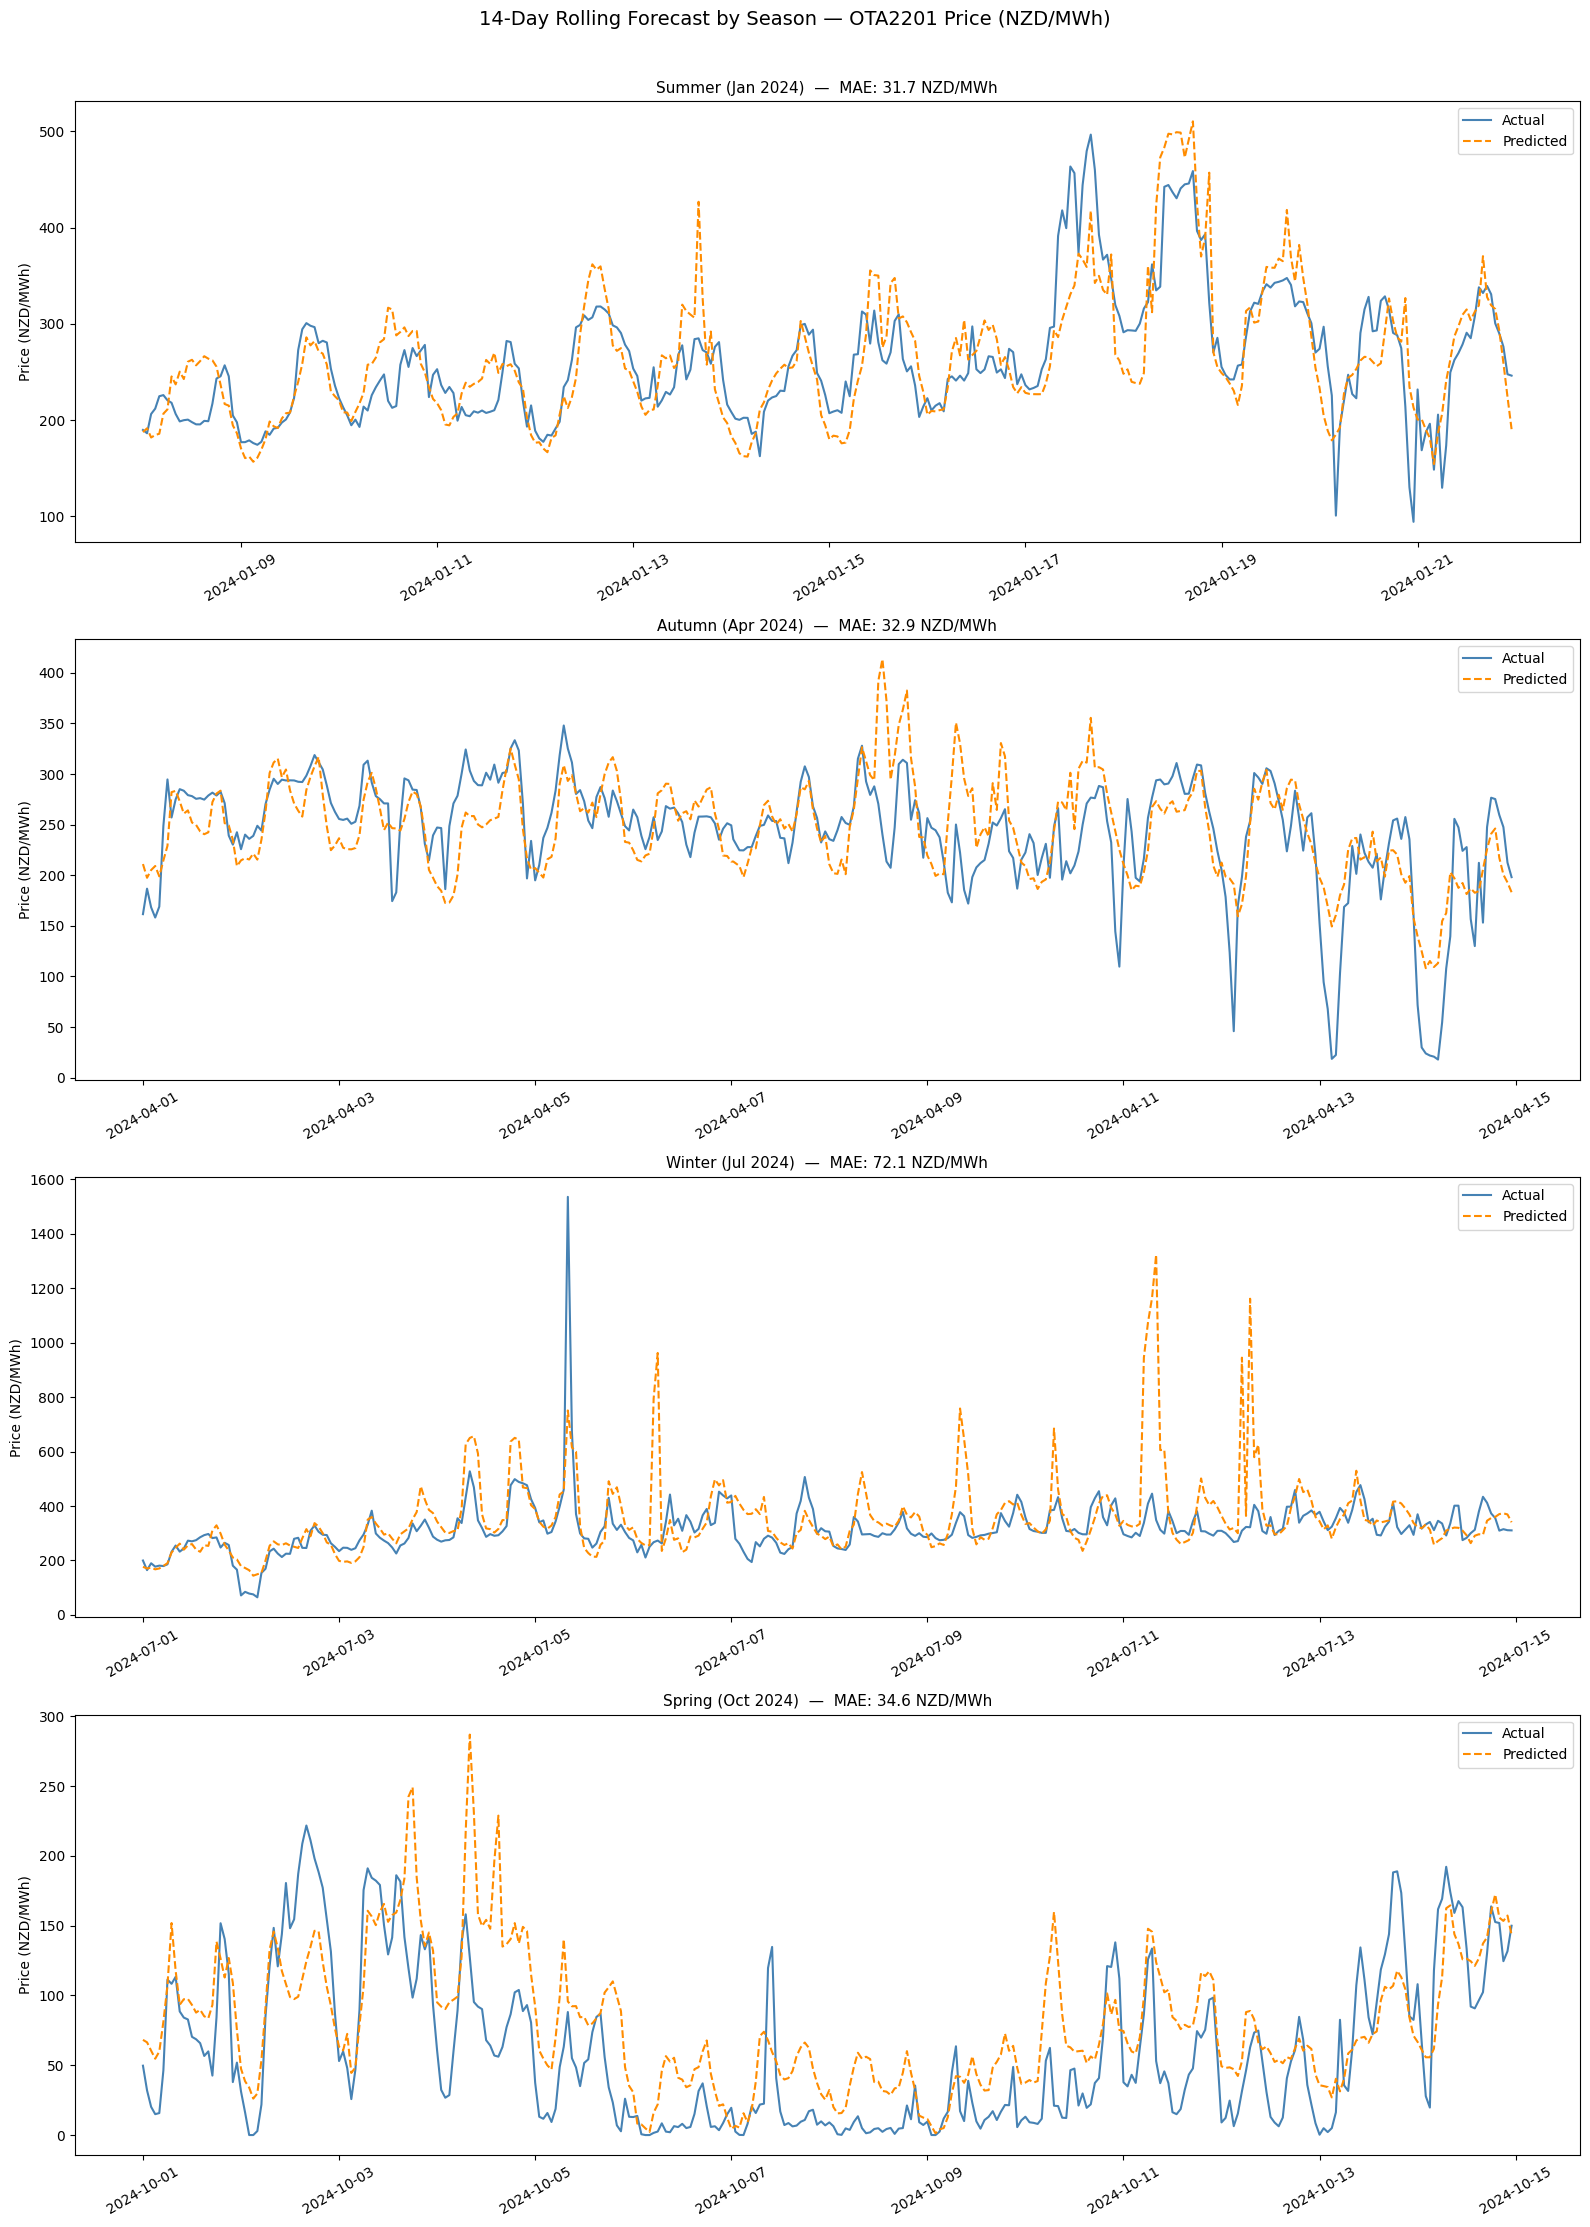

In [117]:
# ---------------------------------------------------
# Seasonal 14-day Rolling Forecasts — NZ 2024
# ---------------------------------------------------
# NZ seasons (Southern Hemisphere):
#   Summer : January
#   Autumn : April
#   Winter : July
#   Spring : October
#
# Each 14-day window is from the test period (2024).
# Forecast is chained 24h-by-24h using the function above.

seasons = {
    "Summer (Jan 2024)": "2024-01-08",
    "Autumn (Apr 2024)": "2024-04-01",
    "Winter (Jul 2024)": "2024-07-01",
    "Spring (Oct 2024)": "2024-10-01",
}

fig, axes = plt.subplots(4, 1, figsize=(16, 22))
fig.suptitle("14-Day Rolling Forecast by Season — OTA2201 Price (NZD/MWh)",
             fontsize=14, y=1.01)

for ax, (season_label, start_date) in zip(axes, seasons.items()):

    preds, actuals, timestamps = rolling_14day_forecast(
        model=xgb_model,
        start_date=start_date
    )

    season_mae = mean_absolute_error(actuals, preds)

    ax.plot(timestamps, actuals, label="Actual",    color="steelblue",  linewidth=1.5)
    ax.plot(timestamps, preds,   label="Predicted", color="darkorange",
            linestyle="--", linewidth=1.5)

    ax.set_title(f"{season_label}  —  MAE: {season_mae:.1f} NZD/MWh", fontsize=11)
    ax.set_ylabel("Price (NZD/MWh)")
    ax.legend(loc="upper right")
    ax.tick_params(axis="x", labelrotation=30)

    print(f"{season_label:25s}  MAE={season_mae:.2f}  start={start_date}")

plt.tight_layout()
plt.show()

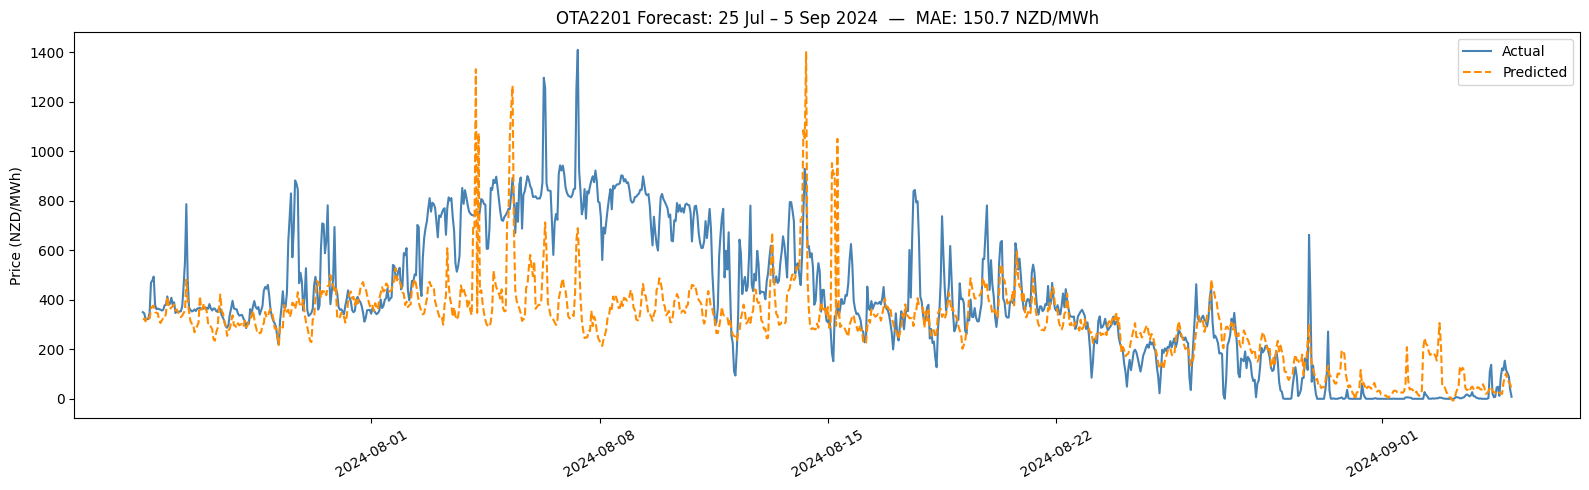

In [118]:
preds, actuals, timestamps = rolling_14day_forecast(
    model=xgb_model,
    start_date="2024-07-25",
    n_days=42
)

mae_custom = mean_absolute_error(actuals, preds)

plt.figure(figsize=(16, 5))
plt.plot(timestamps, actuals, label="Actual",    color="steelblue",  linewidth=1.5)
plt.plot(timestamps, preds,   label="Predicted", color="darkorange",
         linestyle="--", linewidth=1.5)
plt.title(f"OTA2201 Forecast: 25 Jul – 5 Sep 2024  —  MAE: {mae_custom:.1f} NZD/MWh")
plt.ylabel("Price (NZD/MWh)")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()